## Sales Effectiveness 


# Business Case:


•FicZon Inc is an IT solution provider with products ranging from on
premises products to SAAS based solutions. FicZon major leads 
generation channel is digital and through their website. 

•FicZon business is majorly dependent on the sales force 
effectiveness. As the market is maturing and more new competitors 
entering the market, FicZon is experiencing the dip in sales. 

•Effective sales is dependent on lead quality and as of now, this is 
based on manual categorization and highly depended on sales staff. 
Though there is a quality process, which continuously updates the 
lead categorization, it’s value is in for post analysis, rather than 
conversation.

•FicZon wants to explore Machine Learning to pre-categorize the lead 
quality and as result, expecting significant increase in sales 
effectiveness. 

# PROJECT GOAL:

1. Data exploration insights – Sales effectiveness. 

2. ML model to predict the Lead Category (High Potential , Low 
Potential) 

## Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Importing Data From Server

PyMySQL is an interface for connecting to a MySQL database server from Python. It implements the Python Database API v2. 0 and contains a pure-Python MySQL client library. The goal of PyMySQL is to be a drop-in replacement for MySQLdb.

In [2]:
!pip install pymysql
!pip install mysql-connector

Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import os
import mysql.connector

### making connections to database server

In [4]:
connection=mysql.connector.connect(host = '18.136.157.135',user='dm_team2',
                                  password='DM!$Team&27@9!20!')

### Check the number of databases available on the server

In [5]:
cursor=connection.cursor()
cursor.execute('show databases')
for i in cursor:
    print(i)

('information_schema',)
('project_sales',)


### connecting the database

In [6]:
connection=mysql.connector.connect(host='18.136.157.135',
                                  user='dm_team2',
                                  password='DM!$Team&27@9!20!',
                                  database = 'project_sales')

In [7]:
query = 'select * from data'

### Importing raw data through SQL Server

In [8]:
data = pd.read_sql(query,connection)

## Basic Checks

In [9]:
data

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


## Domain Analysis :-

•Created - Created is date and time on which the lead was generated.

•Product_ID - Product_ID is the Serial no. of the product.

•Source - Source ,from where the lead has generated like website , phonecall , email etc.

•Mobile - Mobile number of the lead or customer

•EMAIL - EMAIL of the lead.

•Sales_Agent - Sales_Agent is the agent who generated the lead.

•Location - Location is the address of the lead / from where the lead has generated.

•Delivery_Mode - how the product has deliveried to lead or what type of delivery mode.

•Status - Status of current lead .


### To visualize the No.of.rows & columns

In [10]:
data.shape

(7422, 9)

### To visualize first 5 rows

In [11]:
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


### To visualize last 5 rows

In [12]:
data.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


## Data Distribution

In [13]:
data['Created'].value_counts()

Created
26-09-2018 11:30    4
27-09-2018 11:00    4
10-05-2018 12:30    4
15-10-2018 10:36    4
14-09-2018 12:00    4
                   ..
29-08-2018 12:52    1
29-08-2018 13:08    1
29-08-2018 15:26    1
29-08-2018 15:39    1
28-04-2018 07:54    1
Name: count, Length: 6752, dtype: int64

In [14]:
data['Product_ID'].unique()

array(['', '9', '19', '18', '15', '27', '5', '2', '3', '25', '10', '20',
       '11', '21', '1', '12', '13', '17', '24', '26', '16', '23', '22',
       '8', '14', '6', '0', '28', '7', '4'], dtype=object)

In [15]:
data['Product_ID'].value_counts()

Product_ID
18    1711
15    1518
19    1189
9      992
27     739
5      487
10     168
1      105
20     102
25      90
21      66
        58
2       38
12      36
26      31
14      27
11      12
22       8
3        7
17       7
6        7
8        6
13       5
24       3
16       3
23       2
0        2
28       1
7        1
4        1
Name: count, dtype: int64

In [16]:
data['Source'].unique()

array(['Website', '', 'Live Chat-Google Organic', 'Call',
       'Live Chat-Direct', 'By Recommendation', 'Customer Referral',
       'Live Chat-Blog', 'Live Chat -PPC', 'Live Chat-Google Ads',
       'Live Chat-Adwords Remarketing', 'E-Mail Message',
       'Existing Client', 'Live Chat-CPC', 'Existing Customer',
       'Live Chat-Quora', 'US Website', 'Just Dial', 'Campaign', 'Other',
       'E-mail Campaign', 'CRM form', 'SMS Campaign', 'Personal Contact',
       'Live Chat-Youtube', 'Live Chat-Justdial'], dtype=object)

In [17]:
data['Source'].value_counts()

Source
Call                             2547
Live Chat-Direct                 1834
Website                          1594
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 180
US Website                        137
Just Dial                          56
Existing Client                    51
Personal Contact                   50
Live Chat-CPC                      50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
                                   17
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Live Chat-Quora                     2
Other                               2
SMS Campaign                        2
Live Chat-Youtube                   2
E-Mail Message                      1
Live Chat-Justdial                  1
Name:

In [18]:
data['Mobile'].value_counts()

Mobile
              1810
XXXXXXX        222
988XXXXXXX     211
984XXXXXXX     177
998XXXXXXX     125
              ... 
610XXXXXXX       1
(41XXXXXXX       1
78 XXXXXXX       1
88 XXXXXXX       1
436XXXXXXX       1
Name: count, Length: 487, dtype: int64

In [19]:
data['Sales_Agent'].unique()

array(['Sales-Agent-11', 'Sales-Agent-10', 'Sales-Agent-3',
       'Sales-Agent-4', 'Sales-Agent-9', 'Sales-Agent-7', '',
       'Sales-Agent-8', 'Sales-Agent-5', 'Sales-Agent-2',
       'Sales-Agent-12', 'Sales-Agent-1', 'Sales-Agent-6'], dtype=object)

In [20]:
data['Sales_Agent'].value_counts()

Sales_Agent
Sales-Agent-4     1500
Sales-Agent-11    1420
Sales-Agent-5     1190
Sales-Agent-9      879
Sales-Agent-3      781
Sales-Agent-7      736
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
Sales-Agent-10      49
                    23
Sales-Agent-1        4
Name: count, dtype: int64

In [21]:
data['Location'].unique()

array(['', 'Bangalore', 'Other Locations', 'UAE', 'Trivandrum',
       'Hyderabad', 'Chennai', 'UK', 'USA', 'Delhi', 'Mumbai', 'Kolkata',
       'Singapore', 'Pune', 'AUSTRALIA', 'EUROPE', 'Malaysia', 'Howrah'],
      dtype=object)

In [22]:
data['Location'].value_counts()

Location
Other Locations    2500
Bangalore          2084
Chennai             909
Hyderabad           528
Delhi               471
Mumbai              402
Pune                142
UAE                  79
                     58
Trivandrum           58
Kolkata              55
USA                  45
UK                   41
AUSTRALIA            25
Singapore            17
Malaysia              4
EUROPE                3
Howrah                1
Name: count, dtype: int64

In [23]:
data['Delivery_Mode'].unique()

array(['Mode-5', 'Mode-1', 'Mode-3', 'Mode-2', 'Mode-4'], dtype=object)

In [24]:
data['Delivery_Mode'].value_counts()

Delivery_Mode
Mode-5    2975
Mode-1    2627
Mode-3    1688
Mode-4     121
Mode-2      11
Name: count, dtype: int64

In [25]:
data['Status'].unique()

array(['Open', 'Potential', 'In Progress Positive', 'Not Responding',
       'Just Enquiry', 'Junk Lead', 'CONVERTED', 'In Progress Negative',
       'LOST', 'Long Term', 'converted'], dtype=object)

In [26]:
data['Status'].value_counts()

Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
converted                 18
Name: count, dtype: int64

### Data Description

In [27]:
data.describe()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7422,7422,7422,7422,7422,7422,7422,7422
unique,6752,30,26,487,883,13,18,5,11
top,26-09-2018 11:30,18,Call,,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,1711,2547,1810,1701,1500,2500,2975,1536


### Insights from Description

* The dataset contains 7422 entries related to sales leads or transactions.
* 'Call' seems to be the primary source of leads, and 'Sales-Agent-4' is a significant contributor, suggesting specific agents may handle a substantial volume of leads.
* A large number of entries have missing or erroneous data in the 'EMAIL' field, indicated by '#VALUE!', which might require cleaning or investigation.
* 'Other Locations' seem to be a common entry in the 'Location' field, which might need further categorization or clarification.
* The most frequent status being 'Junk Lead' suggests a significant portion of leads may not be viable for conversion, indicating potential issues with lead quality or targeting.


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


## Insights from info() :-
•Created is Datetime Column but it is in Objective ( Convert it into datetime64).

•Product_ID is a integer but it is in float.

•Source is a String with few missing values.

•Mobile number is an integer but it is in float with missing values .

•EMAIL is string.

•Sales_Agent , Location are objects with missing values.

### To visualize the columns

In [29]:
data.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

##  EDA (Exploratory Data Analysis)

In [30]:
# Convert Created Column from object datatype to datetime data type

data['Created'] = data['Created'].astype('datetime64[ns]')

In [31]:
# Make a different columns for Year , Month , Date , Hour , Minute.
data['Year'] = data['Created'].dt.year
data['Month'] = data['Created'].dt.month
data['Day'] = data['Created'].dt.day
data['Hour'] = data['Created'].dt.hour
data['Minutes'] = data['Created'].dt.minute

In [32]:
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Year,Month,Day,Hour,Minutes
0,2018-11-14 10:05:00,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open,2018,11,14,10,5
1,2018-11-14 09:22:00,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open,2018,11,14,9,22
2,2018-11-14 09:21:00,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open,2018,11,14,9,21
3,2018-11-14 08:46:00,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open,2018,11,14,8,46
4,2018-11-14 07:34:00,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open,2018,11,14,7,34


## Univariate analysis

In [33]:
pip install sweetviz

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [34]:
import sweetviz as sv
report=sv.analyze(data)
report.show_html()

                                             |                                             | [  0%]   00:00 ->…

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Source

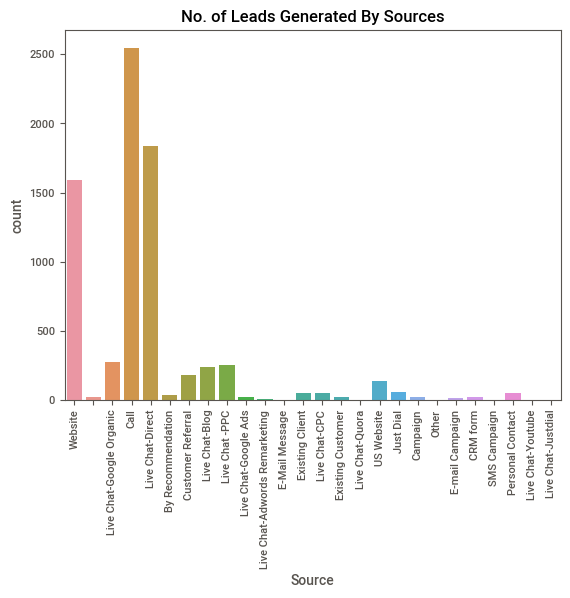

In [35]:
sns.countplot(x=data.Source)
plt.title("No. of Leads Generated By Sources")
plt.xticks(rotation=90)
plt.show()

### Insights from Source:-

•34 % Leads were generarted from Call Source .

•25 % Leads were Generated from live direct chat .

•21 % Leads were generated from their Website .

•11 % Leads were generated from Live chat in Google , PPC , Blog and US Website.

remaining 10 % leads were generated from other sources .

### Sales_Agent

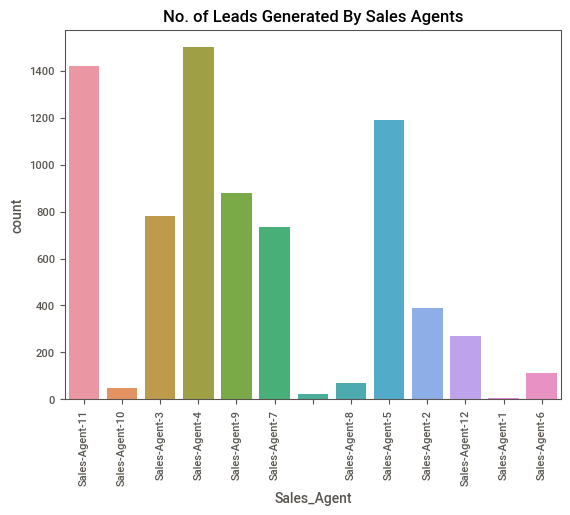

In [36]:
sns.countplot(x=data.Sales_Agent)
plt.title("No. of Leads Generated By Sales Agents")
plt.xticks(rotation=90)
plt.show()

### Insights For Sales Agent:-

•Agent-3 , Agent-4 , Agent-5 , Agent-7 , Agent-9 and Agent-11 togatherly Generated More than 87 % Leads.

•Agent-1 , Agent-2 , Agent-6 , Agent-8 , Agent-10 and Agent-12 are togatherly Generated less than 13 % Leads.

### Location

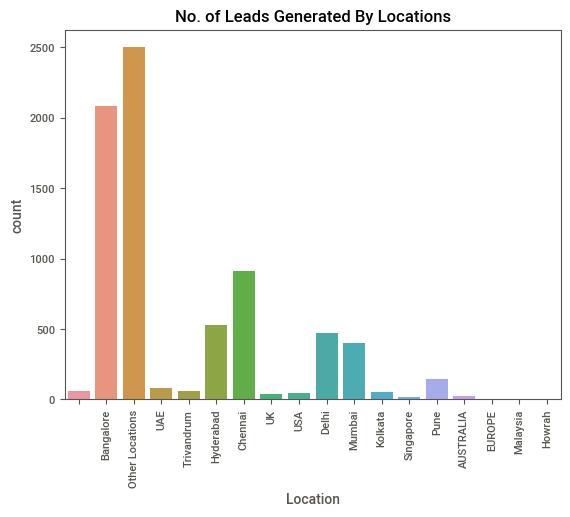

In [37]:
sns.countplot(x=data.Location)
plt.title("No. of Leads Generated By Locations")
plt.xticks(rotation=90)
plt.show()

### Insights from Location:-

•33 % Leads were generated from Other Locations.

•from Bangalore 28% and Chennai 12% Leads were Generated.

•From Hyderabad 7% , Delhi 6% and Mumbai 5% Leads were Generated.

### Delivery_Mode

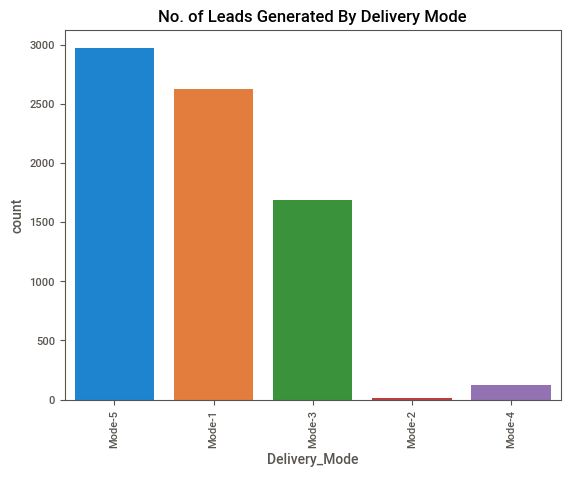

In [38]:
sns.countplot(x=data.Delivery_Mode)
plt.title("No. of Leads Generated By Delivery Mode")
plt.xticks(rotation=90)
plt.show()

### Insights from Delivery mode:-
•Most of Leads prefered Mode-5 , Mode-1 ,Mode-3

### Status

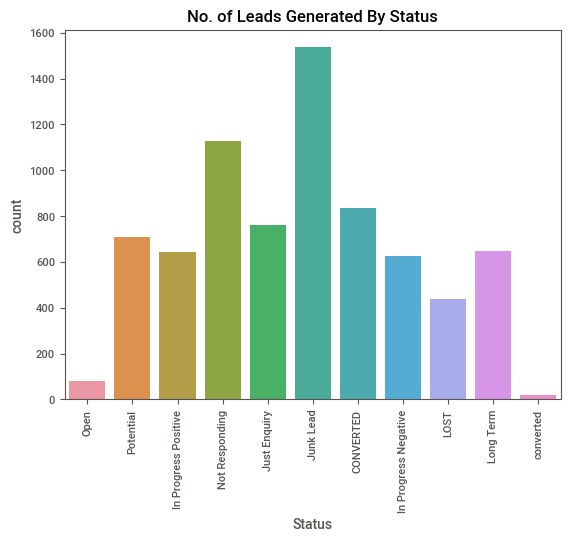

In [39]:
sns.countplot(x=data.Status)
plt.title("No. of Leads Generated By Status")
plt.xticks(rotation=90)
plt.show()

### Insights from Status :-

•20 % Leads which are generated , they are Junk Leads.

•15 % Leads were Not Responding.

•11 % Leads got Convorted .(Successed)

•10 % Leads are just Enquired.


### Month

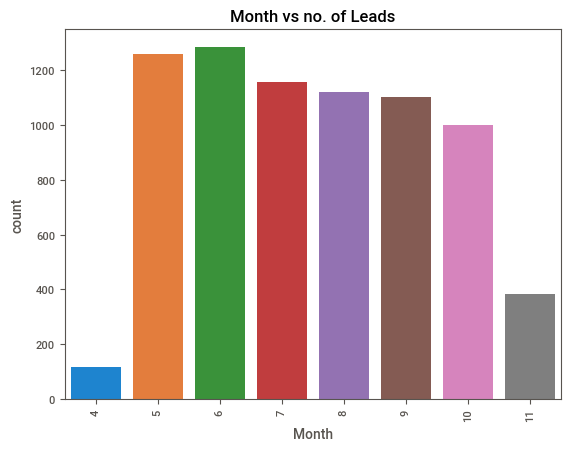

In [40]:
sns.countplot(x=data.Month)
plt.xticks(rotation=90)
plt.title("Month vs no. of Leads")
plt.show()

### Insights from Month:-
•76% Leads were generated between May to October month.

## Bi - Variate Analysis

### Preprocessing for Bi-Variate Analysis :-
•According to Business Case we have to combine target Classes and differnciate into Two Categories.

•High Potential - CONVERTED,Potential,In Progress Positive,converted .

•Low Potential - Junk Lead, Not Responding, Just Enquiry, Long Term, In Progress Negative, LOST and Open

In [41]:
# High Potential Leads

data.loc[data['Status']=="CONVERTED",'Status'] = "High Potential"
data.loc[data['Status']=='Potential',"Status"] = "High Potential"
data.loc[data['Status']=='In Progress Positive',"Status"] = "High Potential"
data.loc[data['Status']=="converted" , 'Status'] = "High Potential"


# Low POtential Leads

data.loc[data['Status']=="Junk Lead",'Status'] = "Low Potential"
data.loc[data['Status']=="Not Responding",'Status'] = "Low Potential"
data.loc[data['Status']=="Just Enquiry",'Status'] = "Low Potential"
data.loc[data['Status']=="Long Term",'Status'] = "Low Potential"
data.loc[data['Status']=='In Progress Negative',"Status"] = "Low Potential"
data.loc[data['Status']=="LOST",'Status'] = "Low Potential"
data.loc[data['Status']=='Open',"Status"] = "Low Potential"

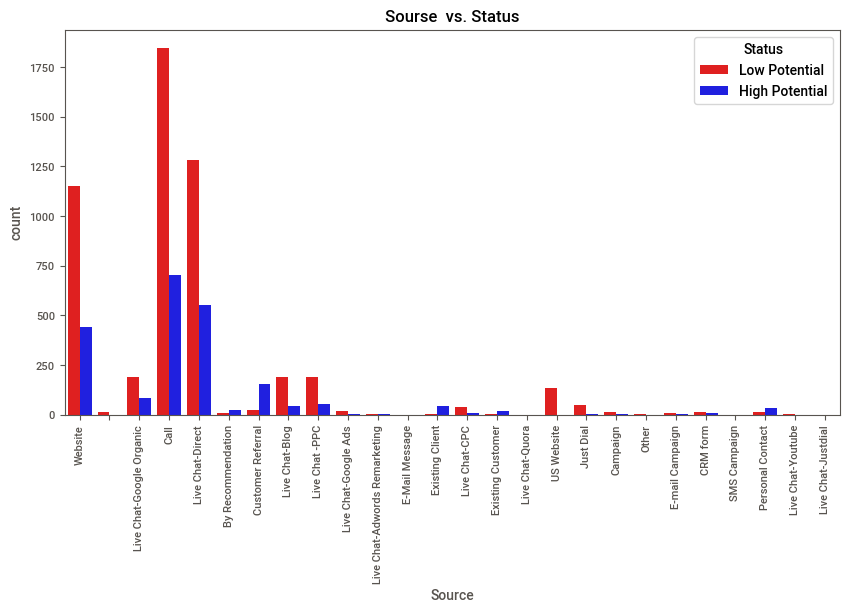

In [42]:
plt.figure(figsize=(10,5))
sns.countplot(x=data.Source,hue=data.Status,palette=['Red','Blue'])
plt.title(" Sourse  vs. Status ")
plt.xticks(rotation=90)
plt.show()

### Insights (Sources vs Status) :-
•Leads Generated by the following have high potential are : - by Recommendation - Customer Referral - Existing Client - Existing Customer - Personal Contact

•Leads Generated By the following have approximately 50% Chance for High Potential are : - Website - Live Chat Google Organic - Call - Live Chat Direct - Live Chat Blog - Live Chat PPC

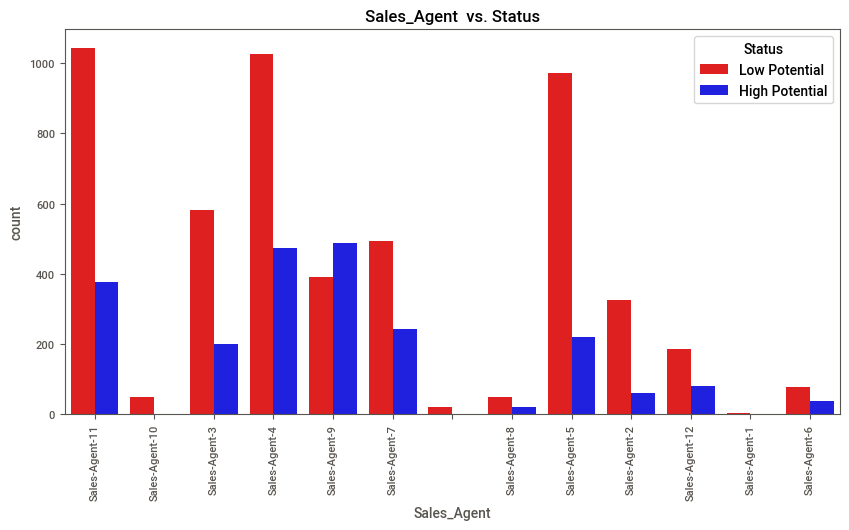

In [43]:
plt.figure(figsize=(10,5))
sns.countplot(x=data.Sales_Agent,hue=data.Status,palette=['Red','Blue'])
plt.title(" Sales_Agent  vs. Status ")
plt.xticks(rotation=90)
plt.show()

### Insights (Agent vs Potential) :-
•Leads Generated by Sales-Agent-9 have High Potential.

•Leads Generated by Sales-Agent-10 and Sales-Agent-1 have Low Potential.

•Leads Generated by other Agents have more than 40 % High Potential .

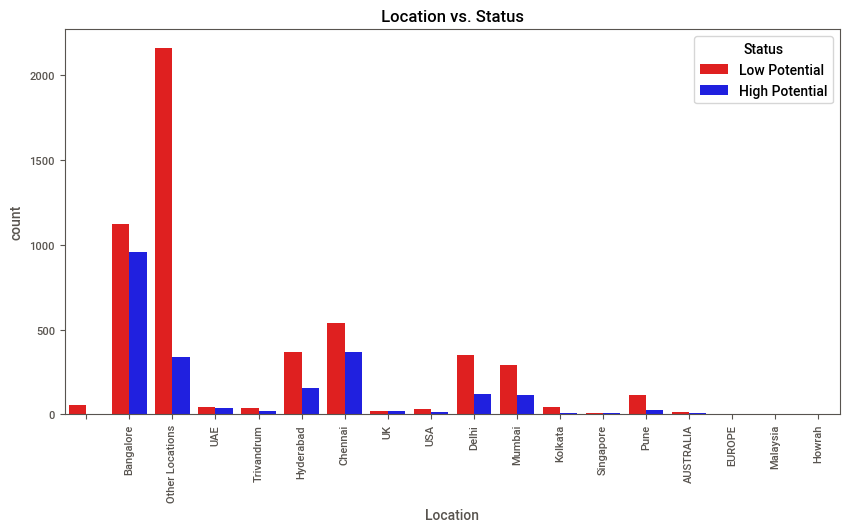

In [44]:
plt.figure(figsize=(10,5))
sns.countplot(x=data.Location,hue=data.Status,palette=['Red','Blue'])
plt.title(" Location vs. Status ")
plt.xticks(rotation=90)
plt.show()


### Insights (Location vs Status ) :-
•Leads Generated in Bangalore , UAE , UK , USA and AUSTRALIA having High Potential.

•only 40 % Leads have High potential which Leads are Generated in Mumbai , Delhi , Hydrabad , Chennai and remaining 60 % has Low Potential

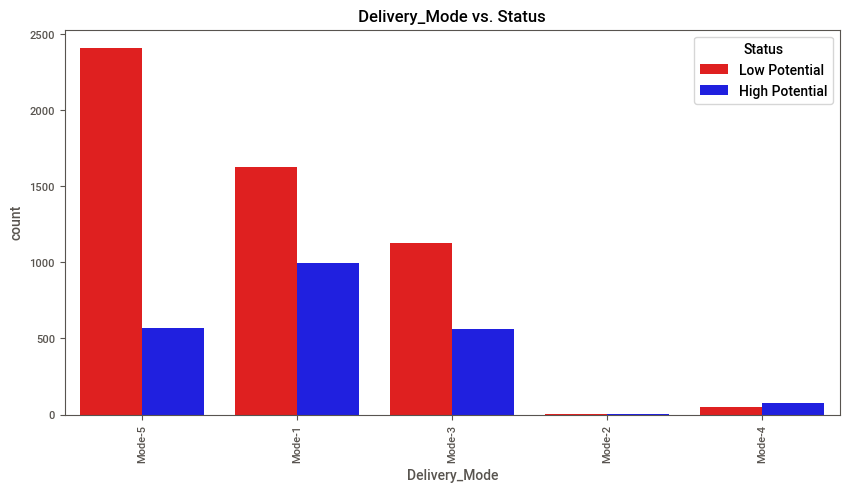

In [45]:
plt.figure(figsize=(10,5))
sns.countplot(x=data.Delivery_Mode,hue=data.Status,palette=['Red','Blue'])
plt.title(" Delivery_Mode vs. Status ")
plt.xticks(rotation=90)
plt.show()

### Insights (Delivery Mode vs. Status ) :-
•Leads who choose delivery MODE-5 , they have low chance of having High Potential as compared to other.

•High Potential Leads choose MODE-4 as delivery mode.n

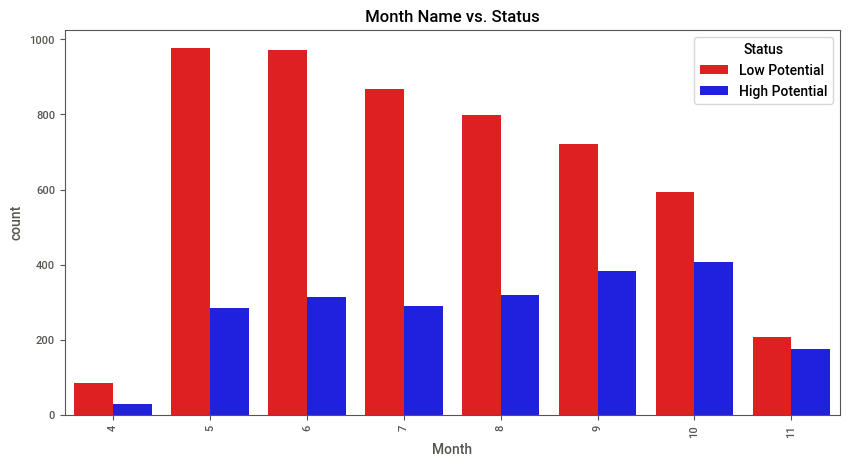

In [46]:
plt.figure(figsize=(10,5))
sns.countplot(x=data.Month,hue=data.Status,palette=['Red','Blue'])
plt.title(" Month Name vs. Status ")
plt.xticks(rotation=90)
plt.show()

### Insights (Month Name vs Status) :-
    
•Leads Not dependent on Month for High Potential or Low Potential

## Plotting the labels in each column

<Axes: xlabel='Status'>

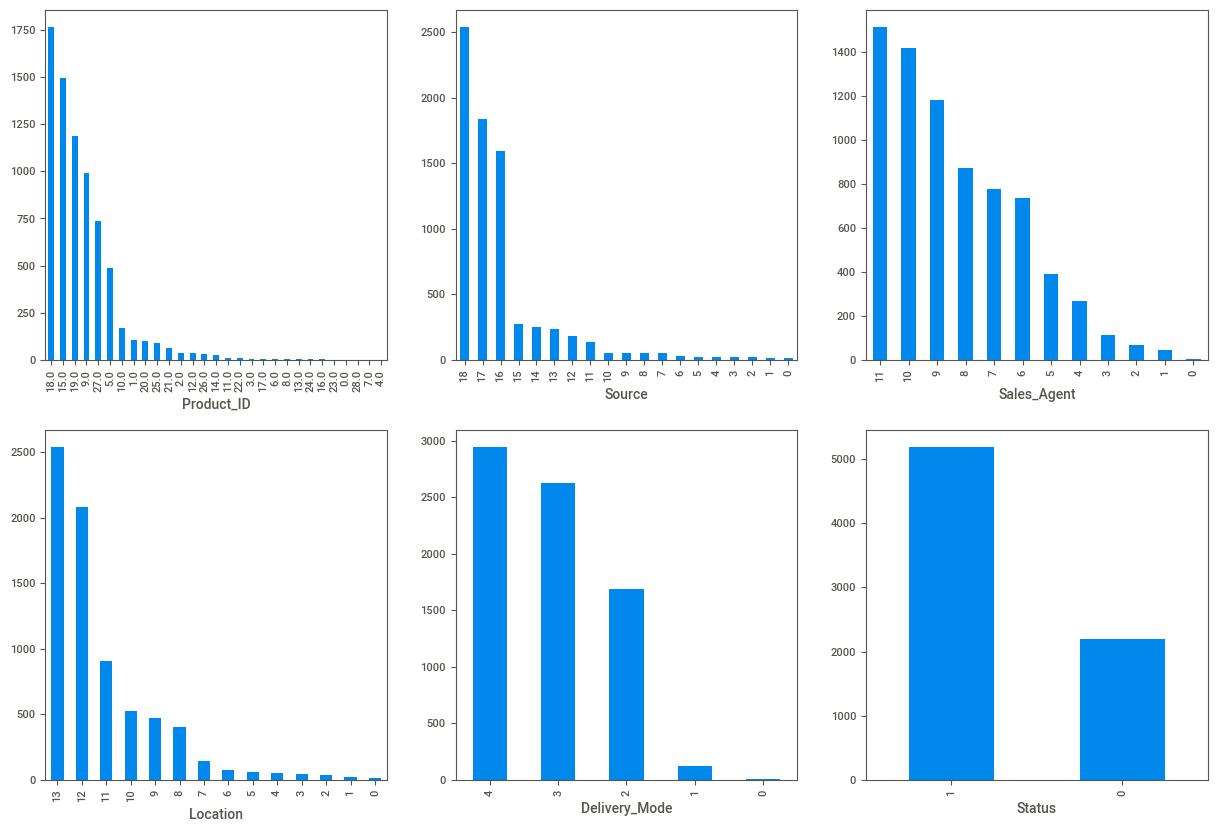

In [176]:
plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
data.Product_ID.value_counts().plot(kind='bar')
plt.subplot(2,3,2)
data.Source.value_counts().plot(kind='bar')
plt.subplot(2,3,3)
data.Sales_Agent.value_counts().plot(kind='bar')
plt.subplot(2,3,4)
data.Location.value_counts().plot(kind='bar')
plt.subplot(2,3,5)
data.Delivery_Mode.value_counts().plot(kind='bar')
plt.subplot(2,3,6)
data.Status.value_counts().plot(kind='bar')

## DATA PREPROCESSING

In [47]:
# drop unnecessary columns which we created.
data.drop(['Created','Mobile','EMAIL'],axis=1,inplace=True)

### Null Values

In [48]:
data.isnull().sum()

Product_ID       0
Source           0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
Year             0
Month            0
Day              0
Hour             0
Minutes          0
dtype: int64

In [49]:
# Change Space value with NaN.
for i in data.columns :
    data.loc[data[i]=='',i] = np.nan

In [50]:
# Find null Values present in each columns and handle them
data.isnull().sum()

Product_ID       58
Source           17
Sales_Agent      23
Location         58
Delivery_Mode     0
Status            0
Year              0
Month             0
Day               0
Hour              0
Minutes           0
dtype: int64

In [51]:
# Product_ID is in object so, change it into float data type
data['Product_ID'] = data['Product_ID'].astype('float')

In [52]:
## null values are there , so handle them.
data.loc[data['Product_ID'].isnull(),'Product_ID'] = data['Product_ID'].median()

data.loc[data['Source'].isnull(),'Source'] = data['Source'].mode()[0]
data.loc[data['Sales_Agent'].isnull(),'Sales_Agent'] = data['Sales_Agent'].mode()[0]
data.loc[data['Location'].isnull(),'Location'] = data['Location'].mode()[0]

## Encoding

### Product_ID :-

In [53]:
# Value count for Source
data.Product_ID.value_counts()

Product_ID
18.0    1769
15.0    1518
19.0    1189
9.0      992
27.0     739
5.0      487
10.0     168
1.0      105
20.0     102
25.0      90
21.0      66
2.0       38
12.0      36
26.0      31
14.0      27
11.0      12
22.0       8
3.0        7
17.0       7
6.0        7
8.0        6
13.0       5
24.0       3
16.0       3
23.0       2
0.0        2
28.0       1
7.0        1
4.0        1
Name: count, dtype: int64

In [54]:
data.Product_ID.replace({22.0 : 0.0,3.0 : 0.0 , 17.0:0.0 , 6.0:0.0 , 8.0:0.0 , 13.0:0.0 ,
                          24.0:0.0 , 16.0:0.0 , 23.0:0.0 , 0.0:0.0 , 28.0:0.0 , 7.0:0.0 , 4.0:0.0})

0       18.0
1       18.0
2       18.0
3       18.0
4       18.0
        ... 
7417     9.0
7418    15.0
7419     5.0
7420    21.0
7421    25.0
Name: Product_ID, Length: 7422, dtype: float64

### Source :-

In [55]:
# Value count for Source
data.Source.value_counts()

Source
Call                             2564
Live Chat-Direct                 1834
Website                          1594
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 180
US Website                        137
Just Dial                          56
Existing Client                    51
Personal Contact                   50
Live Chat-CPC                      50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Live Chat-Quora                     2
Other                               2
SMS Campaign                        2
Live Chat-Youtube                   2
E-Mail Message                      1
Live Chat-Justdial                  1
Name: count, dtype: int64

In [56]:
# combine below 12 value counts into one variable for better prediction
data.Source.replace({"Live Chat-Adwords Remarketing":"Other","Live Chat-Quora":"Other","SMS Campaign":"Other",
                     "Live Chat-Youtube":"Other","E-Mail Message":"Other","Live Chat-Justdial":"Other"},inplace=True)

In [57]:
data.Source.value_counts()

Source
Call                        2564
Live Chat-Direct            1834
Website                     1594
Live Chat-Google Organic     274
Live Chat -PPC               249
Live Chat-Blog               237
Customer Referral            180
US Website                   137
Just Dial                     56
Existing Client               51
Live Chat-CPC                 50
Personal Contact              50
By Recommendation             32
CRM form                      23
Existing Customer             22
Live Chat-Google Ads          21
Campaign                      19
Other                         17
E-mail Campaign               12
Name: count, dtype: int64

In [58]:
# manually change all categorical data to numerical
data.Source.replace({"Call":18,"Live Chat-Direct":17,"Website":16,"Live Chat-Google Organic":15,"Live Chat -PPC":14,
      "Live Chat-Blog":13,"Customer Referral":12,"US Website":11,"Just Dial":10,"Existing Client":9,"Live Chat-CPC":8,
      "Personal Contact":7,"By Recommendation":6,"CRM form":5,"Existing Customer":4,"Live Chat-Google Ads":3,"Campaign":2,
      "Other":1,"E-mail Campaign":0},inplace=True)

### Sales Agents :-

In [59]:
data.Sales_Agent.value_counts()

Sales_Agent
Sales-Agent-4     1523
Sales-Agent-11    1420
Sales-Agent-5     1190
Sales-Agent-9      879
Sales-Agent-3      781
Sales-Agent-7      736
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
Sales-Agent-10      49
Sales-Agent-1        4
Name: count, dtype: int64

In [60]:
# Manually convert Categorical to numerical
data.Sales_Agent.replace({"Sales-Agent-4":11,"Sales-Agent-11":10,"Sales-Agent-5":9,"Sales-Agent-9":8,"Sales-Agent-3":7,
"Sales-Agent-7":6,"Sales-Agent-2":5,"Sales-Agent-12":4,"Sales-Agent-6":3,"Sales-Agent-8":2,"Sales-Agent-10":1,
                         "Sales-Agent-1":0},inplace=True)

### Location:-

In [61]:
# value counts for Locations
data.Location.value_counts()

Location
Other Locations    2558
Bangalore          2084
Chennai             909
Hyderabad           528
Delhi               471
Mumbai              402
Pune                142
UAE                  79
Trivandrum           58
Kolkata              55
USA                  45
UK                   41
AUSTRALIA            25
Singapore            17
Malaysia              4
EUROPE                3
Howrah                1
Name: count, dtype: int64

In [62]:
# Combine low value counts Locations into Othere Location
data.Location.replace({"Malaysia":"Other Locations","EUROPE":"Other Locations","Howrah":"Other Locations"},inplace=True)

In [63]:
# Change categorical to numerical
data.Location.replace({"Other Locations":13,"Bangalore":12,"Chennai":11,"Hyderabad":10,"Delhi":9,"Mumbai":8,"Pune":7,"UAE":6,
"Trivandrum":5,"Kolkata":4,"USA":3,"UK":2,"AUSTRALIA":1,"Singapore":0},inplace=True)

### Delivery Mode :-

In [64]:
# value counts for Delivery mode
data.Delivery_Mode.value_counts()

Delivery_Mode
Mode-5    2975
Mode-1    2627
Mode-3    1688
Mode-4     121
Mode-2      11
Name: count, dtype: int64

In [65]:
# Manually convert Categorical to numerical
data.Delivery_Mode.replace({"Mode-5":4,"Mode-1":3,"Mode-3":2,"Mode-4":1,"Mode-2":0},inplace=True)

### Status :-

In [66]:
# Value counts for Status
data.Status.value_counts()

Status
Low Potential     5219
High Potential    2203
Name: count, dtype: int64

In [67]:
# manually change to numerical
data['Status'] = data['Status'].map({'High Potential': 0 ,'Low Potential': 1})

In [68]:
data.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status,Year,Month,Day,Hour,Minutes
0,18.0,16,10,13,4,1,2018.0,11.0,14.0,10.0,5.0
1,18.0,16,1,13,4,1,2018.0,11.0,14.0,9.0,22.0
2,18.0,16,1,13,4,1,2018.0,11.0,14.0,9.0,21.0
3,18.0,16,1,13,4,1,2018.0,11.0,14.0,8.0,46.0
4,18.0,16,1,13,4,1,2018.0,11.0,14.0,7.0,34.0


In [69]:
data.isnull().sum()

Product_ID       0
Source           0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
Year             0
Month            0
Day              0
Hour             0
Minutes          0
dtype: int64

## Outlier

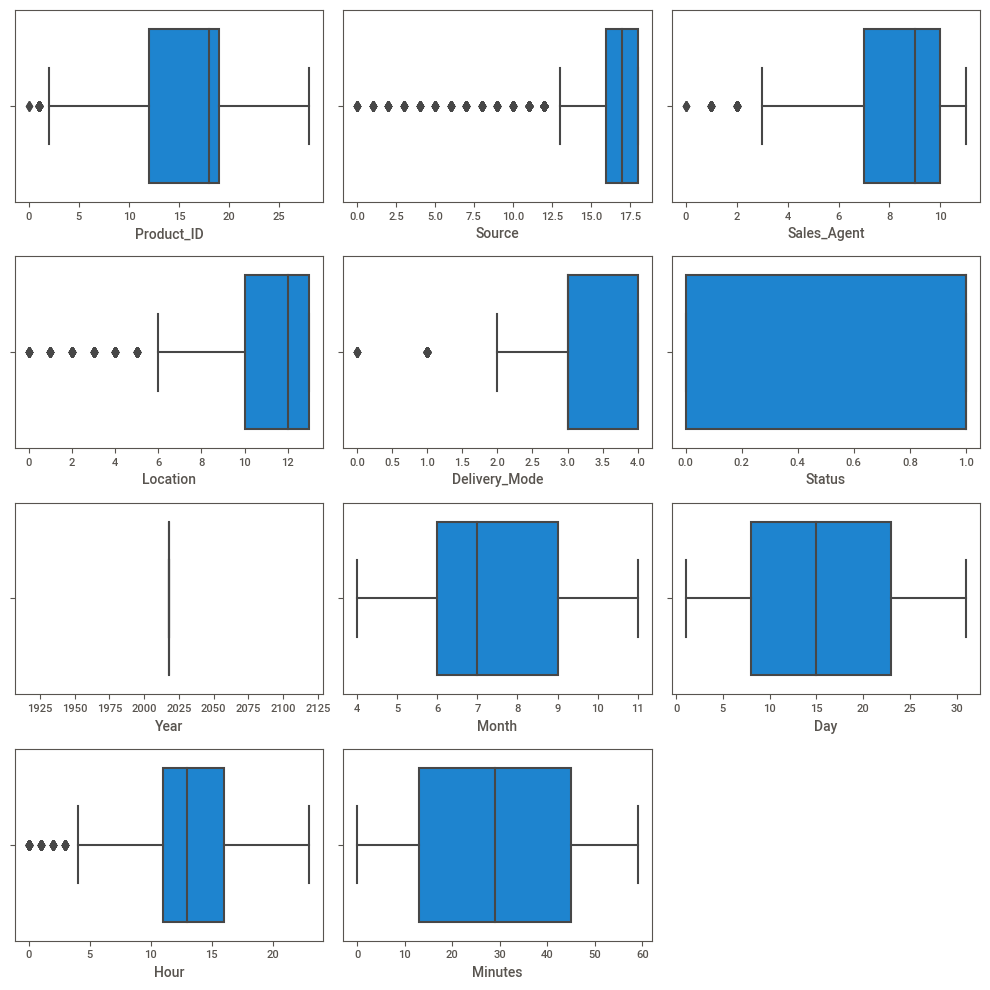

In [70]:
plt.figure(figsize=(10,10))
plotnumber = 1
for i in data.columns:
    plt.subplot(4,3,plotnumber)
    sns.boxplot(x = data[i])
    plotnumber = plotnumber + 1
plt.tight_layout()

### Insights from Box-plot :

•we can not change any thing because these all are descrete values

## Scaling data

In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

data[['Month','Day','Hour','Minutes']] = pd.DataFrame(scaler.fit_transform(data[['Month','Day','Hour','Minutes']]))


## FEATURE SELECTION

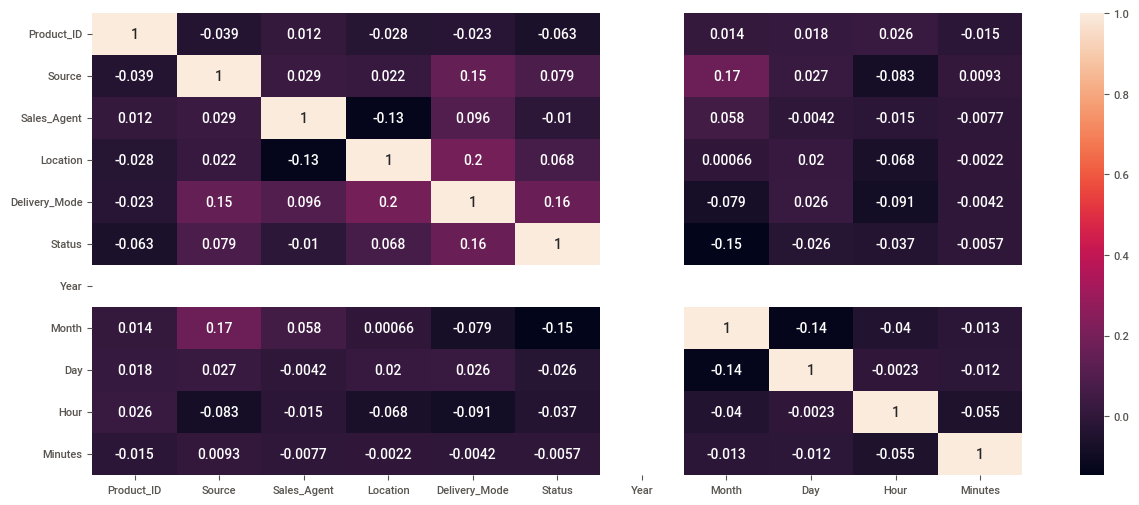

In [72]:
plt.figure(figsize=(15,6))
sns.heatmap(data.corr(),annot=True)
plt.show()

### insights from Heatmap :-
•Year has one value , so it's not required.

•Minutes & Day_name has also little or no corelation with target class.

## Duplicate Value checking

In [73]:
data.duplicated().sum()

27

In [74]:
# Drop Duplicate Values for accurate prediction
data.shape

(7422, 11)

In [75]:
data.drop_duplicates(inplace=True)

In [76]:
# Drop Duplicate Values for accurate prediction
data.shape

(7395, 11)

In [77]:
data.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status,Year,Month,Day,Hour,Minutes
0,18.0,16,10,13,4,1,2018.0,1.864294,-0.182295,-0.821831,-1.365239
1,18.0,16,1,13,4,1,2018.0,1.864294,-0.182295,-1.068420,-0.382515
2,18.0,16,1,13,4,1,2018.0,1.864294,-0.182295,-1.068420,-0.440323
3,18.0,16,1,13,4,1,2018.0,1.864294,-0.182295,-1.315009,1.004859
4,18.0,16,1,13,4,1,2018.0,1.864294,-0.182295,-1.561598,0.311172


## Create dependent & Independent Features

In [78]:
X = data.drop(["Status","Year"],axis=1)
y = data["Status"]

## Dependent & Independent variable Creating

In [79]:
# InDependent Variable
X.tail()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Month,Day,Hour,Minutes
7417,9.0,18,3,8,1,-1.863719,1.366386,-1.068420,0.947051
7418,15.0,18,4,13,4,-1.863719,1.366386,-1.068420,0.831437
7419,5.0,17,10,12,3,-1.863719,1.366386,-1.068420,-0.498130
7420,21.0,5,11,13,3,-1.863719,1.366386,-1.315009,-1.423046
7421,25.0,16,7,11,3,-1.863719,1.366386,-1.561598,1.467317


In [80]:
# Dependent Variable
y.tail()

7417    1
7418    1
7419    1
7420    1
7421    0
Name: Status, dtype: int64

## Split Data into Train & Test

In [81]:
# Split data into train & test using train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=95)

## MODEL CREATION 

### Logistic Regression`

In [82]:
from sklearn.linear_model import LogisticRegression                 
log = LogisticRegression()                                         
log.fit(X_train,y_train)  

LogisticRegression()

In [83]:
y_log_pr = log.predict(X_test)   

In [84]:
y_log_pr

array([1, 0, 1, ..., 1, 1, 1], dtype=int64)

In [85]:
y_test.values

array([1, 1, 0, ..., 1, 1, 1], dtype=int64)

In [86]:
from sklearn.metrics import accuracy_score, classification_report,f1_score,precision_score

In [87]:
log_pr=precision_score(y_test,y_log_pr)
log_pr

0.7434782608695653

In [88]:
Acc_log = accuracy_score(y_test,y_log_pr)
print(f'Accuracy of Logistic Regression is = {Acc_log}')

Accuracy of Logistic Regression is = 0.718052738336714


In [89]:
print(classification_report(y_test,y_log_pr))

              precision    recall  f1-score   support

           0       0.36      0.09      0.15       390
           1       0.74      0.94      0.83      1089

    accuracy                           0.72      1479
   macro avg       0.55      0.52      0.49      1479
weighted avg       0.64      0.72      0.65      1479



•Overall Model Performance: The model achieves an accuracy of 72%, indicating that it correctly predicts the target variable for about 72% of the samples.

Class-wise Performance:

•For class 0, the model has a precision of 36% and recall of 9%. This means that when the model predicts a sample as class 0, it is correct 36% of the time, but it only correctly identifies 9% of the actual class 0 samples.

•For class 1, the model has a precision of 74% and recall of 94%. This means that when the model predicts a sample as class 1, it is correct 74% of the time, and it correctly identifies 94% of the actual class 1 samples.

•F1-score: The weighted average F1-score is 0.65, indicating a moderate balance between precision and recall for both classes.

•Support: Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.

## Balancing data

In [90]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=38)
X_smote , y_smote = smote.fit_resample(X_train,y_train)

### Model Evaluation  for Logistic Regression after Data Balancing

In [91]:
log.fit(X_smote,y_smote)                                            
y_log = log.predict(X_test)    
acc_log_smote=accuracy_score(y_test,y_log)
print(f'Accuracy of Logistic Regression after Smoting is = {acc_log_smote}')

Accuracy of Logistic Regression after Smoting is = 0.6362407031778229


In [92]:
precision_score(y_test,y_log)

0.8010928961748633

In [93]:
print(classification_report(y_test,y_log))

              precision    recall  f1-score   support

           0       0.37      0.53      0.44       390
           1       0.80      0.67      0.73      1089

    accuracy                           0.64      1479
   macro avg       0.58      0.60      0.58      1479
weighted avg       0.69      0.64      0.65      1479



•Overall Model Performance: The model achieves an accuracy of 64%, indicating that it correctly predicts the target variable for about 64% of the samples.

Class-wise Performance:

•For class 0, the model has a precision of 37% and recall of 53%. This means that when the model predicts a sample as class 0, it is correct 37% of the time, and it correctly identifies 53% of the actual class 0 samples.

•For class 1, the model has a precision of 80% and recall of 67%. This means that when the model predicts a sample as class 1, it is correct 80% of the time, and it correctly identifies 67% of the actual class 1 samples.

•F1-score: The weighted average F1-score is 0.65, indicating a reasonable balance between precision and recall for both classes.

•Support: Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.



## Support vector Machine

In [94]:
from sklearn.svm import SVC                      
svm = SVC()                        
svm.fit(X_smote,y_smote)                          

SVC()

In [95]:
y_svm = svm.predict(X_test) 

In [96]:
precision_score(y_test,y_svm)

0.8163030998851895

In [97]:
acc_svm = accuracy_score(y_test,y_svm)
print(f'Accuracy of Support Vector : {acc_svm}')

Accuracy of Support Vector : 0.6362407031778229


In [98]:
print(classification_report(y_test,y_svm))

              precision    recall  f1-score   support

           0       0.38      0.59      0.46       390
           1       0.82      0.65      0.73      1089

    accuracy                           0.64      1479
   macro avg       0.60      0.62      0.59      1479
weighted avg       0.70      0.64      0.66      1479



•Overall Model Performance: The model achieves an accuracy of 64%, indicating that it correctly predicts the target variable for about 64% of the samples.

Class-wise Performance:

•For class 0, the model has a precision of 38% and recall of 59%. This means that when the model predicts a sample as class 0, it is correct 38% of the time, and it correctly identifies 59% of the actual class 0 samples.

•For class 1, the model has a precision of 82% and recall of 65%. This means that when the model predicts a sample as class 1, it is correct 82% of the time, and it correctly identifies 65% of the actual class 1 samples.

•F1-score: The weighted average F1-score is 0.66, indicating a reasonable balance between precision and recall for both classes.

•Support: Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.

### Hyperparameter Tunning of Support Vector 

In [99]:
hyperpara_svm =  {
    'C' : [10,1.0 , 0.1 , 0.001],             
    'kernel' : ['linear', 'rbf', 'sigmoid'],
    'gamma' : [10,1,0.1]
}

from sklearn.model_selection import GridSearchCV

grid_svm = GridSearchCV(estimator=SVC(random_state=0), 
                       param_grid=hyperpara_svm,
                       scoring='accuracy',
                       cv=3,
                       verbose=3,
                       n_jobs=-1 )          

grid_svm.fit(X_smote,y_smote)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=SVC(random_state=0), n_jobs=-1,
             param_grid={'C': [10, 1.0, 0.1, 0.001], 'gamma': [10, 1, 0.1],
                         'kernel': ['linear', 'rbf', 'sigmoid']},
             scoring='accuracy', verbose=3)

In [100]:
print(f'Best Score is : {grid_svm.best_score_}')
print(f'Best Parameters : {grid_svm.best_params_}')

Best Score is : 0.8401559454191032
Best Parameters : {'C': 10, 'gamma': 1, 'kernel': 'rbf'}


In [101]:
svm_hyp = SVC(C=10,kernel='rbf',gamma=1)
svm_hyp.fit(X_smote,y_smote)

SVC(C=10, gamma=1)

In [102]:
y_hyp_svm = svm_hyp.predict(X_test)

acc_hyp_svm = accuracy_score(y_test,y_hyp_svm)
print(f'Accuracy of Support Vector after hyperparameter = {acc_hyp_svm}')

Accuracy of Support Vector after hyperparameter = 0.7349560513860717


In [103]:
precision_score(y_test,y_hyp_svm)

0.7821862348178138

In [104]:
print(classification_report(y_test,y_hyp_svm))

              precision    recall  f1-score   support

           0       0.50      0.31      0.38       390
           1       0.78      0.89      0.83      1089

    accuracy                           0.73      1479
   macro avg       0.64      0.60      0.61      1479
weighted avg       0.71      0.73      0.71      1479



•Overall Model Performance: The model achieves an accuracy of 73%, indicating that it correctly predicts the target variable for about 73% of the samples.

Class-wise Performance:

•For class 0 (presumably the minority class), the model has a lower precision of 50%, indicating that when it predicts a sample as class 0, it is correct only 50% of the time. The recall for class 0 is 31%, indicating that the model correctly identifies only 31% of the actual class 0 samples.

•For class 1 (presumably the majority class), the model has a higher precision of 78%, indicating that when it predicts a sample as class 1, it is correct 78% of the time. The recall for class 1 is 89%, indicating that the model correctly identifies 89% of the actual class 1 samples.

•F1-score: The F1-score is a harmonic mean of precision and recall and provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.71, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.

## Decision Tree

In [105]:
from sklearn.tree import DecisionTreeClassifier     
tree = DecisionTreeClassifier()       
tree.fit(X_smote,y_smote)                           

DecisionTreeClassifier()

In [106]:
y_tree = tree.predict(X_test)                       

acc_tree = accuracy_score(y_test,y_tree)
print(f'Accuracy of Decision Tree = {acc_tree}')

Accuracy of Decision Tree = 0.6903313049357674


In [107]:
precision_score(y_test,y_tree)

0.8066083576287658

In [108]:
print(classification_report(y_test,y_tree))

              precision    recall  f1-score   support

           0       0.42      0.49      0.45       390
           1       0.81      0.76      0.78      1089

    accuracy                           0.69      1479
   macro avg       0.62      0.63      0.62      1479
weighted avg       0.71      0.69      0.70      1479



•Overall Model Performance: The model achieves an accuracy of 69%, indicating that it correctly predicts the target variable for about 69% of the samples.

Class-wise Performance:

•For class 0, the model has a precision of 42% and recall of 49%. This means that when the model predicts a sample as class 0, it is correct 42% of the time, and it correctly identifies 49% of the actual class 0 samples

•For class 1, the model has a precision of 81% and recall of 76%. This means that when the model predicts a sample as class 1, it is correct 81% of the time, and it correctly identifies 76% of the actual class 1 samples.

•F1-score: The weighted average F1-score is 0.70, indicating a reasonable balance between precision and recall for both classes.

•Support: Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.



### Hyperparameter Tunning of Decision Tree

In [109]:
hyperpara_tree  =  {
    'criterion' : ["gini", "entropy"],
    'splitter' : ["best", "random"],
    "max_depth":[10,20,30,40],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [1,2,3]
}


from sklearn.model_selection import RandomizedSearchCV


random_tree = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=91),
                                 param_distributions=hyperpara_tree,
                                 n_jobs = -1,
                                 scoring = 'accuracy',
                                 cv=3,
                                 verbose=3
                                )

random_tree.fit(X_smote,y_smote)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=91),
                   n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [10, 20, 30, 40],
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [2, 3, 4, 5],
                                        'splitter': ['best', 'random']},
                   scoring='accuracy', verbose=3)

In [110]:
print(f'Best Score is : {random_tree.best_score_}')
print(f'Best Parameters : {random_tree.best_params_}')

Best Score is : 0.7289230019493177
Best Parameters : {'splitter': 'best', 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_depth': 40, 'criterion': 'entropy'}


In [154]:
tree_hyp = DecisionTreeClassifier(criterion='entropy',
                                 splitter='best',
                                 min_samples_split=3,
                                 min_samples_leaf=1,
                                 max_depth=40)
tree_hyp.fit(X_smote,y_smote)

DecisionTreeClassifier(criterion='entropy', max_depth=40, min_samples_split=3)

In [155]:
y_hyp_tree = tree_hyp.predict(X_test)

acc_hyp_tree = accuracy_score(y_test,y_hyp_tree)
print(f'Accuracy of Decision Tree after hyperparameter = {acc_hyp_tree}')

Accuracy of Decision Tree after hyperparameter = 0.6768086544962812


In [156]:
precision_score(y_test,y_hyp_tree)

0.8082744702320888

In [157]:
print(classification_report(y_test,y_hyp_tree))

              precision    recall  f1-score   support

           0       0.41      0.51      0.46       390
           1       0.81      0.74      0.77      1089

    accuracy                           0.68      1479
   macro avg       0.61      0.62      0.61      1479
weighted avg       0.70      0.68      0.69      1479



•Overall Model Performance: The model achieves an accuracy of 68%, indicating that it correctly predicts the target variable for about 68% of the samples.

Class-wise Performance:

•For class 0 (presumably the minority class), the model has a precision of 41% and recall of 51%. This indicates that when the model predicts a sample as class 0, it is correct 41% of the time, and it correctly identifies 51% of the actual class 0 samples.

•For class 1 (presumably the majority class), the model has a precision of 81% and recall of 74%. This indicates that when the model predicts a sample as class 1, it is correct 81% of the time, and it correctly identifies 74% of the actual class 1 samples.

•F1-score: The F1-score, which is the harmonic mean of precision and recall, provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.69, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.

## Random Forest

In [115]:
from sklearn.ensemble import RandomForestClassifier     
r_forest = RandomForestClassifier()      
r_forest.fit(X_smote,y_smote)                           

RandomForestClassifier()

In [116]:
y_pr_forest = r_forest.predict(X_test)                  
acc_forest = accuracy_score(y_test,y_pr_forest)
print(f'Accuracy of random forest = {acc_forest}')

Accuracy of random forest = 0.7349560513860717


In [117]:
precision_score(y_test,y_pr_forest)

0.8136813681368137

In [118]:
print(classification_report(y_test,y_pr_forest))

              precision    recall  f1-score   support

           0       0.50      0.47      0.48       390
           1       0.81      0.83      0.82      1089

    accuracy                           0.73      1479
   macro avg       0.66      0.65      0.65      1479
weighted avg       0.73      0.73      0.73      1479



•Overall Model Performance: The model achieves an accuracy of 73%, indicating that it correctly predicts the target variable for about 73% of the samples.

Class-wise Performance:

•For class 0, the model has a precision of 50% and recall of 47%. This means that when the model predicts a sample as class 0, it is correct 50% of the time, and it correctly identifies 47% of the actual class 0 samples.

•For class 1, the model has a precision of 81% and recall of 83%. This means that when the model predicts a sample as class 1, it is correct 81% of the time, and it correctly identifies 83% of the actual class 1 samples.

•F1-score: The weighted average F1-score is 0.73, indicating a reasonable balance between precision and recall for both classes.

•Support: Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.

### Hyperparameter tunning for Random Forest

In [119]:
hyperpara_forest  =  {
    'n_estimators' : [int(x) for x in np.linspace(200,2000,10)],
    'max_depth' : [int(x) for x in np.linspace(10, 110, num=11)],
    'min_samples_split' : [2,5,7,10],
    'min_samples_leaf' : [1,2,3,4],
    'max_features' : ["sqrt", "auto"] 
}


from sklearn.model_selection import RandomizedSearchCV


grid_forest = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=0),
                                 param_distributions=hyperpara_forest ,
                                  n_iter=100 ,
                                  n_jobs=-1 ,
                                  verbose=1 ,
                                  cv = 3 ,
                                  scoring='accuracy'
                             )

grid_forest.fit(X_smote,y_smote)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=0),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110],
                                        'max_features': ['sqrt', 'auto'],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [2, 5, 7, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   scoring='accuracy', verbose=1)

In [120]:
print(f'Best Score is : {grid_forest.best_score_}')
print(f'Best Parameters : {grid_forest.best_params_}')

Best Score is : 0.8060428849902536
Best Parameters : {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50}


In [158]:
r_forest_hyp = RandomForestClassifier(n_estimators =  600,
                                     min_samples_split = 2,
                                     min_samples_leaf = 1,
                                     max_features =  'sqrt',
                                     max_depth = 50)
r_forest_hyp.fit(X_smote,y_smote)


RandomForestClassifier(max_depth=50, n_estimators=600)

In [159]:
y_hyp_forest = r_forest_hyp.predict(X_test)

acc_hyp_forest = accuracy_score(y_test,y_hyp_forest)
print(f'Accuracy of Random Forest after hyperparameter = {acc_hyp_forest}')

Accuracy of Random Forest after hyperparameter = 0.7430696416497633


In [160]:
precision_score(y_test,y_hyp_forest)

0.8179372197309417

In [161]:
print(classification_report(y_test,y_pr_forest))

              precision    recall  f1-score   support

           0       0.50      0.47      0.48       390
           1       0.81      0.83      0.82      1089

    accuracy                           0.73      1479
   macro avg       0.66      0.65      0.65      1479
weighted avg       0.73      0.73      0.73      1479



•Overall Model Performance: The model achieves an accuracy of 73%, indicating that it correctly predicts the target variable for about 73% of the samples.

Class-wise Performance:

•For class 0 (presumably the minority class), the model has a precision of 50% and recall of 47%. This means that when the model predicts a sample as class 0, it is correct 50% of the time, and it correctly identifies 47% of the actual class 0 samples.

•For class 1 (presumably the majority class), the model has a precision of 81% and recall of 83%. This means that when the model predicts a sample as class 1, it is correct 81% of the time, and it correctly identifies 83% of the actual class 1 samples.

•F1-score: The F1-score, which is the harmonic mean of precision and recall, provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.73, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.



## Naive Bayes

In [125]:
from sklearn.naive_bayes import BernoulliNB,CategoricalNB,GaussianNB   
N_bayes = BernoulliNB()                
N_bayes.fit(X_smote,y_smote)            

BernoulliNB()

In [126]:
y_Bayes = N_bayes.predict(X_test)      
acc_naive_bayes = accuracy_score(y_test,y_Bayes)         
print(f'Accuracy of Naive Bayes is {acc_naive_bayes}')

Accuracy of Naive Bayes is 0.5517241379310345


In [127]:
precision_score(y_test,y_Bayes)

0.7703045685279187

In [128]:
print(classification_report(y_test,y_Bayes))

              precision    recall  f1-score   support

           0       0.30      0.54      0.39       390
           1       0.77      0.56      0.65      1089

    accuracy                           0.55      1479
   macro avg       0.54      0.55      0.52      1479
weighted avg       0.65      0.55      0.58      1479



•Overall Model Performance: The model achieves an accuracy of 55%, indicating that it correctly predicts the target variable for about 55% of the samples.

•Class-wise Performance:

   *For class 0 (presumably the minority class), the model has a precision of 30% and recall of 54%. This means that when the model predicts a sample as class 0, it is correct 30% of the time, and it correctly identifies 54% of the actual class 0 samples.

  *For class 1 (presumably the majority class), the model has a precision of 77% and recall of 56%. This means that when the model predicts a sample as class 1, it is correct 77% of the time, and it correctly identifies 56% of the actual class 1 samples.

•F1-score: The F1-score, which is the harmonic mean of precision and recall, provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.58, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.

## K Nearest Neighbour

In [129]:
from sklearn.neighbors import KNeighborsClassifier        
knn = KNeighborsClassifier(n_neighbors=3)                 
knn.fit(X_smote,y_smote)                                  

KNeighborsClassifier(n_neighbors=3)

In [130]:
y_pr_knn = knn.predict(X_test)                            
acc_knn =accuracy_score(y_test,y_pr_knn)
print(f'Accuracy of k nearest Neighbour = {acc_knn}')

Accuracy of k nearest Neighbour = 0.6659905341446923


In [131]:
precision_score(y_test,y_pr_knn)

0.8316610925306578

In [132]:
print(classification_report(y_test,y_pr_knn))

              precision    recall  f1-score   support

           0       0.41      0.61      0.49       390
           1       0.83      0.69      0.75      1089

    accuracy                           0.67      1479
   macro avg       0.62      0.65      0.62      1479
weighted avg       0.72      0.67      0.68      1479



•Overall Model Performance: The model achieves an accuracy of 67%, indicating that it correctly predicts the target variable for about 67% of the samples.

Class-wise Performance:

•For class 0 (presumably the minority class), the model has a precision of 41% and recall of 61%. This means that when the model predicts a sample as class 0, it is correct 41% of the time, and it correctly identifies 61% of the actual class 0 samples.

•For class 1 (presumably the majority class), the model has a precision of 83% and recall of 69%. This means that when the model predicts a sample as class 1, it is correct 83% of the time, and it correctly identifies 69% of the actual class 1 samples.

•F1-score: The F1-score, which is the harmonic mean of precision and recall, provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.68, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.



### Hyperparameter Tunning of KNN

In [133]:
hyperpara_knn = {
    'n_neighbors':[3,5,7,9,11],                      
    'weights':['uniform', 'distance'],                 
    'metric':['minkowski','euclidean','manhattan']     
}


from sklearn.model_selection import GridSearchCV


grid_knn = GridSearchCV(estimator=KNeighborsClassifier(n_neighbors=3),      
                       param_grid=hyperpara_knn,              
                       scoring='accuracy',                    
                        cv=3,
                        verbose=3
                       )


grid_knn.fit(X_smote,y_smote)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV 1/3] END metric=minkowski, n_neighbors=3, weights=uniform;, score=0.756 total time=   0.1s
[CV 2/3] END metric=minkowski, n_neighbors=3, weights=uniform;, score=0.760 total time=   0.1s
[CV 3/3] END metric=minkowski, n_neighbors=3, weights=uniform;, score=0.803 total time=   0.0s
[CV 1/3] END metric=minkowski, n_neighbors=3, weights=distance;, score=0.766 total time=   0.0s
[CV 2/3] END metric=minkowski, n_neighbors=3, weights=distance;, score=0.769 total time=   0.0s
[CV 3/3] END metric=minkowski, n_neighbors=3, weights=distance;, score=0.811 total time=   0.0s
[CV 1/3] END metric=minkowski, n_neighbors=5, weights=uniform;, score=0.730 total time=   0.1s
[CV 2/3] END metric=minkowski, n_neighbors=5, weights=uniform;, score=0.747 total time=   0.1s
[CV 3/3] END metric=minkowski, n_neighbors=5, weights=uniform;, score=0.785 total time=   0.1s
[CV 1/3] END metric=minkowski, n_neighbors=5, weights=distance;, score=0.750 tota

GridSearchCV(cv=3, estimator=KNeighborsClassifier(n_neighbors=3),
             param_grid={'metric': ['minkowski', 'euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=3)

In [134]:
print(f'Best Score is : {grid_knn.best_score_}')
print(f'Best Parameters : {grid_knn.best_params_}')

Best Score is : 0.79885477582846
Best Parameters : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [135]:
knn_hyp = KNeighborsClassifier(n_neighbors=3,weights='distance',metric='manhattan')
knn_hyp.fit(X_smote,y_smote)

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [136]:
y_hyp_knn = knn_hyp.predict(X_test)

acc_hyp_knn = accuracy_score(y_test,y_hyp_knn)
print(f'Accuracy of K_nearest Neighbour after hyperparameter = {acc_hyp_knn}')

Accuracy of K_nearest Neighbour after hyperparameter = 0.6666666666666666


In [137]:
precision_score(y_test,y_hyp_knn)

0.8211206896551724

In [138]:
print(classification_report(y_test,y_hyp_knn))

              precision    recall  f1-score   support

           0       0.41      0.57      0.48       390
           1       0.82      0.70      0.76      1089

    accuracy                           0.67      1479
   macro avg       0.61      0.64      0.62      1479
weighted avg       0.71      0.67      0.68      1479



•Overall Model Performance: The model achieves an accuracy of 67%, indicating that it correctly predicts the target variable for about 67% of the samples.

Class-wise Performance:

•For class 0 (presumably the minority class), the model has a precision of 41% and recall of 57%. This means that when the model predicts a sample as class 0, it is correct 41% of the time, and it correctly identifies 57% of the actual class 0 samples.

•For class 1 (presumably the majority class), the model has a precision of 82% and recall of 70%. This means that when the model predicts a sample as class 1, it is correct 82% of the time, and it correctly identifies 70% of the actual class 1 samples.

•F1-score: The F1-score, which is the harmonic mean of precision and recall, provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.68, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.



## XG - Boost

In [139]:
from xgboost import XGBClassifier            
xgb = XGBClassifier()                         
xgb.fit(X_smote,y_smote)                     

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [140]:
y_xgb = xgb.predict(X_test)                   
acc_xgb = accuracy_score(y_test,y_xgb)
print(f'Accuracy of XG - Boost = {acc_xgb}')

Accuracy of XG - Boost = 0.7450980392156863


In [141]:
precision_score(y_test,y_xgb)

0.8178571428571428

In [142]:
print(classification_report(y_test,y_xgb))

              precision    recall  f1-score   support

           0       0.52      0.48      0.50       390
           1       0.82      0.84      0.83      1089

    accuracy                           0.75      1479
   macro avg       0.67      0.66      0.66      1479
weighted avg       0.74      0.75      0.74      1479



•Overall Model Performance: The model achieves an accuracy of 75%, indicating that it correctly predicts the target variable for about 75% of the samples.

Class-wise Performance:

•For class 0 (presumably the minority class), the model has a precision of 52% and recall of 48%. This means that when the model predicts a sample as class 0, it is correct 52% of the time, and it correctly identifies 48% of the actual class 0 samples.

•For class 1 (presumably the majority class), the model has a precision of 82% and recall of 84%. This means that when the model predicts a sample as class 1, it is correct 82% of the time, and it correctly identifies 84% of the actual class 1 samples.

•F1-score: The F1-score, which is the harmonic mean of precision and recall, provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.74, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.



### Hyperparameter Tunning of XG-Boost

In [143]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'gamma': [1,0.1,0.2,0.3,0.001,0.0001],
              'learning_rate': [ 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7],
              'max_depth': [5,6,7,8,9,10,11,12,13,14],
              'n_estimators': [100,150,200,250,300],
              'reg_alpha': [0.1,0.2,0.4,0.8,1.6,3.2,6.4],
              'reg_lambda': [0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200]}

random_cv_xgb = RandomizedSearchCV(estimator=XGBClassifier(), scoring='accuracy',param_distributions=param_grid, n_iter=100, cv=3,verbose=1,
                              random_state=42, n_jobs=-1)

random_cv_xgb.fit(X_smote,y_smote)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   n_iter=100, n_jobs=-1,
                   param_distributions={'gamma': [1, 0.1, 0.2, 0.3, 0.001,
                                                  0.0001],
                                        'learning_rate': [0.1, 0.15, 0.2, 0.25,
                                                          0.3, 0.4, 0.5, 0.6,
                                                          0.7],
                                        'max_depth': [5, 6, 7, 8, 9, 10, 11, 12,
                                                      13, 14],
                                        'n_estimators': [100, 150, 200, 250,
                                                         300],
                                        'reg_alpha': [0.1, 0.2, 0.4, 0.8, 1.6,
                                                      3.2, 6.4],
                                        'reg_lambda': [0.1, 0.2, 0.4, 0.8, 1.6,
                                                       3.2, 6.4, 12.8, 25.6,
                                                       51.2, 102.4, 200]},
                   random_state=42, scoring='accuracy', verbose=1)

In [144]:
print("XGB best score : ",random_cv_xgb.best_score_)
print("XGB best parameter : ",random_cv_xgb.best_params_)

XGB best score :  0.7849658869395713
XGB best parameter :  {'reg_lambda': 0.8, 'reg_alpha': 0.1, 'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0.1}


In [145]:
xgb_hyp = XGBClassifier(n_estimators =  250,
                        reg_lambda =  0.8 ,
                        reg_alpha = 0.1 ,
                        learning_rate=0.2 ,
                        max_depth = 10,
                        gamma = 0.1,
                       )

xgb_hyp.fit(X_smote,y_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [146]:
y_hyp_xgb = xgb_hyp.predict(X_test)

acc_hyp_xgb = accuracy_score(y_test,y_hyp_xgb)
print(f'Accuracy of XG - Boost after hyperparameter = {acc_hyp_xgb}')

Accuracy of XG - Boost after hyperparameter = 0.7410412440838404


In [147]:
precision_score(y_test,y_hyp_xgb)

0.8118374558303887

In [148]:
print(classification_report(y_test,y_hyp_xgb))

              precision    recall  f1-score   support

           0       0.51      0.45      0.48       390
           1       0.81      0.84      0.83      1089

    accuracy                           0.74      1479
   macro avg       0.66      0.65      0.65      1479
weighted avg       0.73      0.74      0.74      1479



•Overall Model Performance: The model achieves an accuracy of 74%, indicating that it correctly predicts the target variable for about 74% of the samples.

Class-wise Performance:

•For class 0 (presumably the minority class), the model has a precision of 51% and recall of 45%. This means that when the model predicts a sample as class 0, it is correct 51% of the time, and it correctly identifies 45% of the actual class 0 samples.

•For class 1 (presumably the majority class), the model has a precision of 81% and recall of 84%. This means that when the model predicts a sample as class 1, it is correct 81% of the time, and it correctly identifies 84% of the actual class 1 samples.

•F1-score: The F1-score, which is the harmonic mean of precision and recall, provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.74, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.



## Artificial Neural Network

In [149]:
from sklearn.neural_network import MLPClassifier  
ann = MLPClassifier(random_state=2)              
ann.fit(X_smote,y_smote)                         

MLPClassifier(random_state=2)

In [150]:
y_ann = ann.predict(X_test)                       

acc_ann = accuracy_score(y_test,y_ann)
print(f'Accuracy Score of ANN is : {acc_ann}')

Accuracy Score of ANN is : 0.5997295469912103


In [151]:
precision_score(y_test,y_ann)

0.8485273492286115

In [152]:
print(classification_report(y_test,y_ann))

              precision    recall  f1-score   support

           0       0.37      0.72      0.49       390
           1       0.85      0.56      0.67      1089

    accuracy                           0.60      1479
   macro avg       0.61      0.64      0.58      1479
weighted avg       0.72      0.60      0.62      1479



•Overall Model Performance: The model achieves an accuracy of 60%, indicating that it correctly predicts the target variable for about 60% of the samples.

Class-wise Performance:

•For class 0 (presumably the minority class), the model has a precision of 37% and recall of 72%. This means that when the model predicts a sample as class 0, it is correct 37% of the time, and it correctly identifies 72% of the actual class 0 samples.

•For class 1 (presumably the majority class), the model has a precision of 85% and recall of 56%. This means that when the model predicts a sample as class 1, it is correct 85% of the time, and it correctly identifies 56% of the actual class 1 samples.

•F1-score: The F1-score, which is the harmonic mean of precision and recall, provides a single metric to evaluate the model's performance. The weighted average F1-score is 0.62, indicating a reasonable balance between precision and recall for both classes.

•Support: Support indicates the number of samples for each class. Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.

### Hyperparameter Tunning of Artificial Neural Network

In [ ]:
hyperpara_ann = {
    'hidden_layer_sizes' : [(100,50),(200,100,50),(250,180,70)],
    'activation' : ['identity', 'logistic', 'relu'],
    'alpha' : [0.0001,0.001,0.01,0.1,1],
    'batch_size':[100,200,300,400], 
    'max_iter' : [200,400,500,600,800]
}

random_cv_ann = RandomizedSearchCV(estimator=MLPClassifier(random_state=5),
                                   param_distributions=hyperpara_ann,
                                   n_iter=100,
                                   n_jobs=-1,
                                   cv=3,
                                   verbose=1)

random_cv_ann.fit(X_smote,y_smote)


In [166]:
print("ANN best score : ",random_cv_ann.best_score_)
print("ANN best parameter : ",random_cv_ann.best_params_)

ANN best score :  0.7610867446393762
ANN best parameter :  {'max_iter': 800, 'hidden_layer_sizes': (250, 180, 70), 'batch_size': 200, 'alpha': 0.001, 'activation': 'relu'}


In [167]:
ann_hyp = MLPClassifier(hidden_layer_sizes=(250,180,70),
                       activation='relu',
                       alpha=0.001,
                       batch_size=200,
                       max_iter=800,learning_rate_init=0.01)
ann_hyp.fit(X_smote,y_smote)

MLPClassifier(alpha=0.001, batch_size=200, hidden_layer_sizes=(250, 180, 70),
              learning_rate_init=0.01, max_iter=800)

In [168]:
y_hyp_ann = ann_hyp.predict(X_test)
acc_hyp_ann = accuracy_score(y_test,y_hyp_xgb)
print(f'Accuracy of Artificial Neural Network after hyperparameter = {acc_hyp_ann}')

Accuracy of Artificial Neural Network after hyperparameter = 0.7410412440838404


In [169]:
precision_score(y_test,y_hyp_ann)

0.8381995133819952

In [170]:
print(classification_report(y_test,y_hyp_ann))

              precision    recall  f1-score   support

           0       0.39      0.66      0.49       390
           1       0.84      0.63      0.72      1089

    accuracy                           0.64      1479
   macro avg       0.61      0.65      0.61      1479
weighted avg       0.72      0.64      0.66      1479



•Overall Model Performance: The model achieves an accuracy of 64%, indicating that it correctly predicts the target variable for about 64% of the samples.

•Class-wise Performance:

•For class 0, the model has a precision of 39% and recall of 66%. This means that when the model predicts a sample as class 0, it is correct 39% of the time, and it correctly identifies 66% of the actual class 0 samples.

•For class 1, the model has a precision of 84% and recall of 63%. This means that when the model predicts a sample as class 1, it is correct 84% of the time, and it correctly identifies 63% of the actual class 1 samples.

•F1-score: The weighted average F1-score is 0.66, indicating a reasonable balance between precision and recall for both classes.

•Support: Class 1 has significantly more samples (1089) compared to class 0 (390), indicating a class imbalance.

# Results

In [171]:
results = pd.DataFrame({
    'Models' : ['Logistic Regression','Support Vector','Decision Tree','Random Forest',
                'Naive Bayes','K_nearest Neighbour','XG-Booster','Neural Network'] ,
    
    'Accuracy' : [acc_log_smote, acc_svm, acc_tree, acc_forest, acc_naive_bayes, acc_knn, acc_xgb, acc_ann] ,
    
    'Hyperparameter' : [np.nan , acc_hyp_svm, acc_hyp_tree, acc_hyp_forest , np.nan,acc_hyp_knn,
                        acc_hyp_xgb , acc_hyp_ann]
})

In [172]:
results

,Models,Accuracy,Hyperparameter
0,Logistic Regression,0.636241,NaN
1,Support Vector,0.636241,0.734956
2,Decision Tree,0.690331,0.676809
3,Random Forest,0.734956,0.743070
4,Naive Bayes,0.551724,NaN
5,K_nearest Neighbour,0.665991,0.666667
6,XG-Booster,0.745098,0.741041
7,Neural Network,0.599730,0.741041


•We evaluated seven machine learning models for a classification task. The models were Logistic Regression, Support Vector, Decision Tree, Random Forest, Naive Bayes, K_nearest Neighbour, XG-Booster, and Neural Network.

•It can be observed that the XG-Booster model achieved the highest accuracy of 0.745098. However, it is important to note that the selection of the optimal model may depend on other factors such as interpretability, computational cost, and the specific requirements of the problem at hand.

## Based on the model performance and hyperparameters provided:

1.XGBoost has the highest accuracy of 74.51%.

•It achieves this with an eta (learning rate) of approximately 0.741.

•XGBoost is known for its effectiveness in handling complex datasets and is often a strong choice for classification tasks.

2.Random Forest follows closely with an accuracy of 73.50%.

•It achieves this with around 743 estimators.

•Random Forest is known for its ability to reduce overfitting and handle high-dimensional data.

3.Decision Tree performs reasonably well with an accuracy of 69.03%.

•It uses a max_depth parameter of approximately 0.677.

•Decision trees are simple yet powerful models, but they can be prone to overfitting.

4.Support Vector Machine (SVM) and Logistic Regression both achieve an accuracy of 63.62%.

•SVM uses a regularization parameter C of about 0.735.

•Logistic Regression's hyperparameters are not specified.

•SVM and Logistic Regression are common linear models, but SVM can handle non-linear relationships with the right kernel.

5.K-nearest Neighbors (KNN) achieves an accuracy of 66.60% with approximately 0.667 neighbors.

•KNN is a simple and intuitive algorithm but can be sensitive to the choice of k and the distance metric.

6.Naive Bayes has the lowest accuracy of 55.17%.

•Naive Bayes is known for its simplicity and ability to handle large datasets with many features, but it assumes independence among features.

7.Neural Network has an accuracy of 59.97% with a hyperparameter of approximately 0.741.


In conclusion, XGBoost and Random Forest show the best performance among the models listed. However, further tuning and experimentation with hyperparameters could potentially improve the performance of other models as well.






